In [1]:
# Colab Setup (Run this first)

In [2]:
!pip install litebird_sim rich

# `litebird_sim` noise simulation notebook

To run this notebook, you have several options:

-   If you are running this under Binder, you should already be set!
-   If you are running this under Google Colab, be sure to run the cell with `!pip install…` that is right above the title.
-   If you are running this locally, you should first create and activate a new virtual environment with the commands

    ```
    python -m venv ./my_venv
    source ./my_venv/bin/activate
    ```

    (you can use Conda environments, if you prefer) and install Jupyter and litebird_sim in it:

    ```
    pip install jupyter litebird_sim
    ```

    If you have a local copy of the `litebird_sim` repository cloned from <https://github.com/litebird/litebird_sim> (e.g., because you're part of the Simulation Team!), you can use a _development install_ instead:

    ```
    cd /my/local/copy/litebird_sim
    pip install -e .
    ```

## Set up the environment

In [3]:
# Using this file, we can use "import litebird_sim" even if it is not installed system-wide

We start by importing a few libraries that will be useful in this notebook.

In [4]:
import litebird_sim as lbs
import numpy as np
import matplotlib.pylab as plt
import scipy.signal

%matplotlib inline

## Simulation parameters

We define a small set of detectors representing a two-detector pair at 140 GHz. All noise parameters are set explicitly below.

In [5]:
# Observation parameters
duration_s = 3600.0  # 1 hour of data
sampling_hz = 19.0  # LFT-like sampling rate
random_seed = 42

# Noise parameters (typical LFT 140 GHz values)
net_ukrts = 50.0  # µK√s
fknee_mhz = 20.0  # knee frequency in mHz
fmin_hz = 1e-5  # minimum frequency in Hz
alpha = 1.0  # 1/f spectral slope

## 1. White noise

The simplest noise model is uncorrelated Gaussian (white) noise. Each sample is drawn with standard deviation

$$\sigma = \frac{\mathrm{NET} \cdot \sqrt{f_\mathrm{samp}}}{10^6}\ \mathrm{K}$$

The one-sided power spectral density (as returned by `scipy.signal.welch`) integrates to the total variance, and for a flat spectrum this gives:

$$P_\mathrm{white} = \frac{2\,\sigma^2}{f_\mathrm{samp}} = 2\,\mathrm{NET}^2\ (\mu\mathrm{K}^2/\mathrm{Hz})$$

The factor of 2 arises because `welch` folds the negative-frequency half of the two-sided spectrum onto the positive axis.


In [6]:
det = lbs.DetectorInfo(
    name="det_white",
    net_ukrts=net_ukrts,
    sampling_rate_hz=sampling_hz,
)

sim_white = lbs.Simulation(
    base_path="./output_noise_nb",
    start_time=0,
    duration_s=duration_s,
    random_seed=random_seed,
)
obs_white = sim_white.create_observations(detectors=[det])

lbs.noise.add_noise_to_observations(
    obs_white,
    noise_type="white",
    dets_random=sim_white.dets_random,
)

tod_white = obs_white[0].tod[0]  # first (and only) detector
print(f"Samples: {len(tod_white)},  RMS: {tod_white.std():.3e} K")

Samples: 68400,  RMS: 2.180e-04 K


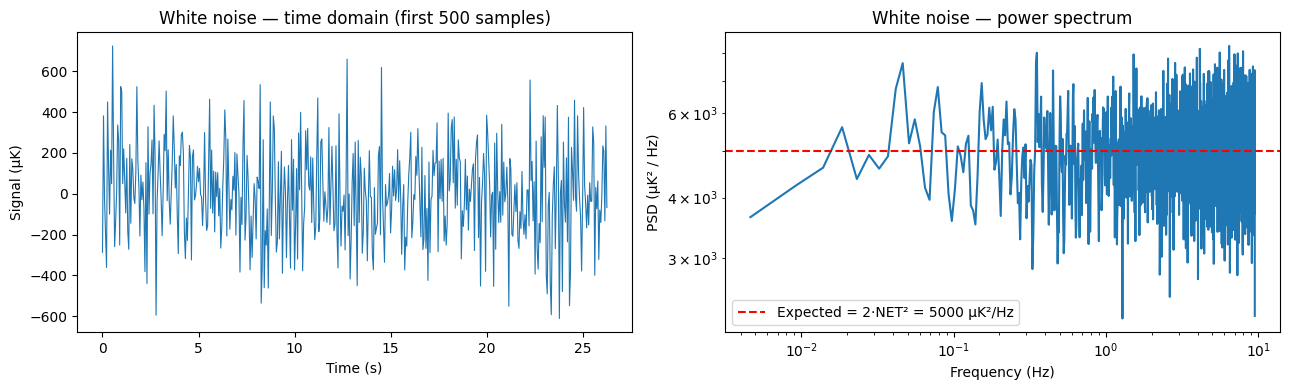

In [17]:
t = np.arange(len(tod_white)) / sampling_hz

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Time domain
axes[0].plot(t[:500], tod_white[:500] * 1e6, lw=0.8)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Signal (µK)")
axes[0].set_title("White noise — time domain (first 500 samples)")

# Power spectral density
f, psd = scipy.signal.welch(tod_white, fs=sampling_hz, nperseg=4096)
axes[1].loglog(f[1:], psd[1:] * 1e12)  # convert K² to µK²
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD (µK² / Hz)")
axes[1].set_title("White noise — power spectrum")

# Expected white noise level.
# scipy.signal.welch returns the one-sided PSD, which folds both positive
# and negative frequencies onto the positive axis, giving a factor of 2:
#   PSD_white = 2 * sigma² / fs = 2 * NET² (µK²/Hz)
sigma_K = net_ukrts * np.sqrt(sampling_hz) / 1e6
expected_psd = 2 * sigma_K**2 / sampling_hz
axes[1].axhline(
    expected_psd * 1e12,
    color="red",
    ls="--",
    label=f"Expected = 2·NET² = {2 * net_ukrts**2:.0f} µK²/Hz",
)
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. 1/f noise

Detector readout chains introduce low-frequency (1/f) noise characterised by the knee frequency $f_\mathrm{knee}$ and spectral index $\alpha$. Two PSD models are available:

| Model | PSD shape |
|-------|-----------|
| `"toast"` (default) | $P(f) \propto (f^\alpha + f_\mathrm{knee}^\alpha)\,/\,(f^\alpha + f_\mathrm{min}^\alpha)$ |
| `"keshner"` | $P(f) \propto \left[(f^2 + f_\mathrm{knee}^2)\,/\,(f^2 + f_\mathrm{min}^2)\right]^{\alpha/2}$ |

and two computational engines: `"fft"` (default, works with both models) and `"ducc"` (IIR filtering, `"keshner"` only).

In [8]:
det_oof = lbs.DetectorInfo(
    name="det_oof",
    net_ukrts=net_ukrts,
    sampling_rate_hz=sampling_hz,
    fknee_mhz=fknee_mhz,
    fmin_hz=fmin_hz,
    alpha=alpha,
)

sim_oof = lbs.Simulation(
    base_path="./output_noise_nb",
    start_time=0,
    duration_s=duration_s,
    random_seed=random_seed,
)
obs_oof = sim_oof.create_observations(detectors=[det_oof])

lbs.noise.add_noise_to_observations(
    obs_oof,
    noise_type="one_over_f",
    dets_random=sim_oof.dets_random,
)

tod_oof = obs_oof[0].tod[0]
print(f"Samples: {len(tod_oof)},  RMS: {tod_oof.std():.3e} K")

Samples: 68400,  RMS: 2.207e-04 K


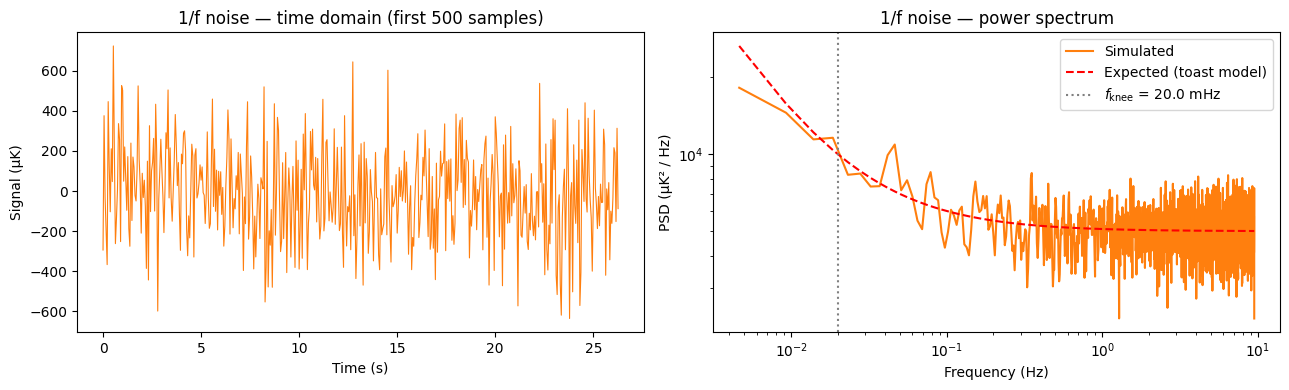

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(t[:500], tod_oof[:500] * 1e6, lw=0.8, color="C1")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Signal (µK)")
axes[0].set_title("1/f noise — time domain (first 500 samples)")

f_oof, psd_oof = scipy.signal.welch(tod_oof, fs=sampling_hz, nperseg=4096)
axes[1].loglog(f_oof[1:], psd_oof[1:] * 1e12, color="C1", label="Simulated")

# Overlay the expected 'toast' PSD shape.
# Factor of 2 accounts for the one-sided (folded) PSD returned by welch.
fknee_hz = fknee_mhz / 1000.0
sigma_K = net_ukrts * np.sqrt(sampling_hz) / 1e6
f_th = f_oof[1:]
psd_white = 2 * sigma_K**2 / sampling_hz  # one-sided white-noise floor
psd_theory = (
    psd_white * (f_th**alpha + fknee_hz**alpha) / (f_th**alpha + fmin_hz**alpha)
)
axes[1].loglog(f_th, psd_theory * 1e12, "r--", label="Expected (toast model)")
axes[1].axvline(
    fknee_hz, color="grey", ls=":", label=f"$f_\\mathrm{{knee}}$ = {fknee_mhz} mHz"
)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD (µK² / Hz)")
axes[1].set_title("1/f noise — power spectrum")
axes[1].legend()

plt.tight_layout()
plt.show()

### Comparing PSD models and engines

Let's overlay the two models and both engines on the same plot to check their consistency.

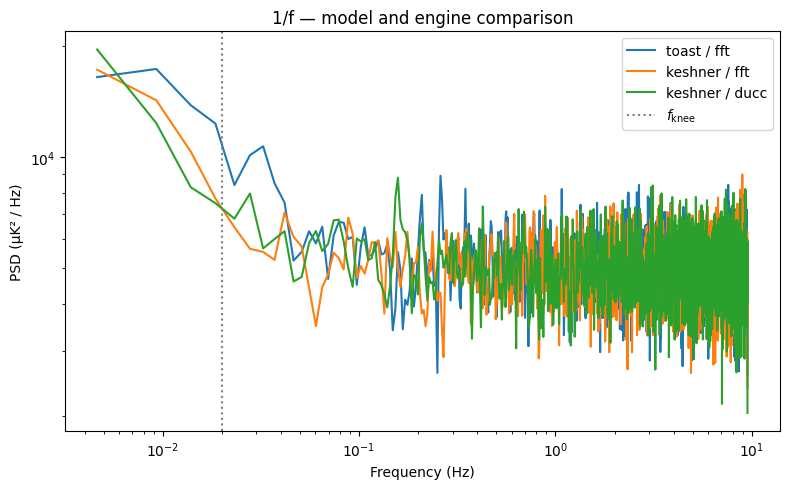

In [10]:
def make_oof_tod(model, engine, seed):
    """Helper: return a 1/f TOD for the given model/engine combination."""
    sim_ = lbs.Simulation(
        base_path="./output_noise_nb",
        start_time=0,
        duration_s=duration_s,
        random_seed=seed,
    )
    obs_ = sim_.create_observations(detectors=[det_oof])
    lbs.noise.add_noise_to_observations(
        obs_,
        noise_type="one_over_f",
        dets_random=sim_.dets_random,
        engine=engine,
        model=model,
    )
    return obs_[0].tod[0]


tod_toast_fft = make_oof_tod("toast", "fft", seed=1)
tod_keshner_fft = make_oof_tod("keshner", "fft", seed=2)
tod_keshner_ducc = make_oof_tod("keshner", "ducc", seed=3)

fig, ax = plt.subplots(figsize=(8, 5))
for tod, label, color in [
    (tod_toast_fft, "toast / fft", "C0"),
    (tod_keshner_fft, "keshner / fft", "C1"),
    (tod_keshner_ducc, "keshner / ducc", "C2"),
]:
    f_, p_ = scipy.signal.welch(tod, fs=sampling_hz, nperseg=4096)
    ax.loglog(f_[1:], p_[1:] * 1e12, label=label)

ax.axvline(fknee_hz, color="grey", ls=":", label="$f_\\mathrm{knee}$")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (µK² / Hz)")
ax.set_title("1/f — model and engine comparison")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Using `Simulation.add_noise`

The high-level `Simulation.add_noise` method is the easiest entry point. It reads noise parameters directly from the detector objects and adds noise in-place to all observations.

In [11]:
dets_pair = [
    lbs.DetectorInfo(
        name=f"det_{i}",
        net_ukrts=net_ukrts,
        sampling_rate_hz=sampling_hz,
        fknee_mhz=fknee_mhz,
        fmin_hz=fmin_hz,
        alpha=alpha,
    )
    for i in range(4)
]

sim = lbs.Simulation(
    base_path="./output_noise_nb",
    start_time=0,
    duration_s=duration_s,
    random_seed=random_seed,
)
sim.create_observations(detectors=dets_pair)

# Add 1/f noise to all detectors in one call
sim.add_noise(noise_type="one_over_f")

obs = sim.observations[0]
for i in range(obs.n_detectors):
    print(f"  det_{i}  RMS = {obs.tod[i].std():.3e} K")

  det_0  RMS = 2.207e-04 K
  det_1  RMS = 2.196e-04 K
  det_2  RMS = 2.197e-04 K
  det_3  RMS = 2.215e-04 K


## 4. Correlated noise

Real detector arrays share thermal and electrical environments, introducing inter-detector correlations. `litebird_sim` provides two correlated-noise models.

### 4a. Common-mode model

Each detector $i$ in group $g$ receives a mixture of a **shared** stream $c_g(t)$ and a **unique** stream $u_i(t)$:

$$n_i(t) = \sqrt{\rho_i}\,c_g(t) + \sqrt{1-\rho_i}\,u_i(t)$$

The parameter $\rho \in [0,1]$ sets the fraction of variance in the common mode ($\rho=0$ → fully independent, $\rho=1$ → identical within a group).

In [12]:
n_dets = 4
dets_corr = [
    lbs.DetectorInfo(
        name=f"det_{i}",
        net_ukrts=net_ukrts,
        sampling_rate_hz=sampling_hz,
        fknee_mhz=fknee_mhz,
        fmin_hz=fmin_hz,
        alpha=alpha,
    )
    for i in range(n_dets)
]

sim_cm = lbs.Simulation(
    base_path="./output_noise_nb",
    start_time=0,
    duration_s=duration_s,
    random_seed=random_seed,
)
sim_cm.create_observations(detectors=dets_corr)

# Group detectors in two pairs; rho=0.7 = 70% common-mode power
sim_cm.add_noise(
    noise_type="correlated",
    correlation={
        "groups": [
            0,
            0,
            1,
            1,
        ],  # det_0 & det_1 share a stream; det_2 & det_3 share another
        "rho": 0.7,
    },
)

tod_cm = sim_cm.observations[0].tod

# Empirical cross-correlation matrix at zero lag
corr_matrix = np.corrcoef(tod_cm)
print("Cross-correlation matrix (common-mode, rho=0.7):")
print(np.round(corr_matrix, 3))

Cross-correlation matrix (common-mode, rho=0.7):
[[ 1.     0.699 -0.002 -0.004]
 [ 0.699  1.    -0.     0.   ]
 [-0.002 -0.     1.     0.697]
 [-0.004  0.     0.697  1.   ]]


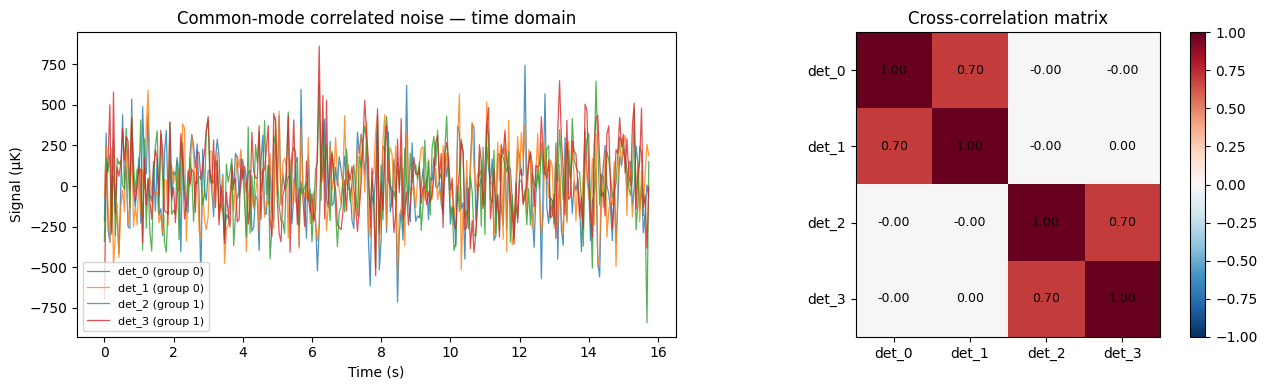

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Time-domain overlay
t_short = np.arange(300) / sampling_hz
colors = ["C0", "C1", "C2", "C3"]
for i in range(n_dets):
    axes[0].plot(
        t_short,
        tod_cm[i, :300] * 1e6,
        lw=0.9,
        alpha=0.8,
        color=colors[i],
        label=f"det_{i} (group {i // 2})",
    )
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Signal (µK)")
axes[0].set_title("Common-mode correlated noise — time domain")
axes[0].legend(fontsize=8)

# Correlation matrix heatmap
im = axes[1].imshow(corr_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar(im, ax=axes[1])
axes[1].set_xticks(range(n_dets))
axes[1].set_yticks(range(n_dets))
axes[1].set_xticklabels([f"det_{i}" for i in range(n_dets)])
axes[1].set_yticklabels([f"det_{i}" for i in range(n_dets)])
axes[1].set_title("Cross-correlation matrix")
for i in range(n_dets):
    for j in range(n_dets):
        axes[1].text(
            j, i, f"{corr_matrix[i, j]:.2f}", ha="center", va="center", fontsize=9
        )

plt.tight_layout()
plt.show()

### 4b. Cholesky (full correlation matrix) model

For arbitrary inter-detector correlations, supply a full $n_\mathrm{det} \times n_\mathrm{det}$ correlation matrix $\mathbf{R}$. The code Cholesky-factors it as $\mathbf{R} = \mathbf{L}\mathbf{L}^T$ and mixes $n_\mathrm{det}$ independent unit-variance noise streams:

$$n_i(t) = \sigma_i \sum_j L_{ij}\,z_j(t)$$

The diagonal of $\mathbf{R}$ should be 1; per-detector scaling is handled automatically via the NET.

In [14]:
# Define a correlation matrix:
#   det_0 and det_1 are strongly correlated (r=0.9)
#   det_2 and det_3 are moderately correlated (r=0.5)
#   cross-pair correlations are weak (r=0.1)
R = np.array(
    [
        [1.0, 0.9, 0.1, 0.1],
        [0.9, 1.0, 0.1, 0.1],
        [0.1, 0.1, 1.0, 0.5],
        [0.1, 0.1, 0.5, 1.0],
    ]
)

sim_chol = lbs.Simulation(
    base_path="./output_noise_nb",
    start_time=0,
    duration_s=duration_s,
    random_seed=random_seed,
)
sim_chol.create_observations(detectors=dets_corr)

sim_chol.add_noise(
    noise_type="correlated",
    correlation={"corr_matrix": R},
)

tod_chol = sim_chol.observations[0].tod

corr_emp = np.corrcoef(tod_chol)
print("Target correlation matrix:")
print(np.round(R, 2))
print("\nEmpirical cross-correlation matrix (Cholesky model):")
print(np.round(corr_emp, 3))

Target correlation matrix:
[[1.  0.9 0.1 0.1]
 [0.9 1.  0.1 0.1]
 [0.1 0.1 1.  0.5]
 [0.1 0.1 0.5 1. ]]

Empirical cross-correlation matrix (Cholesky model):
[[1.    0.901 0.092 0.092]
 [0.901 1.    0.091 0.094]
 [0.092 0.091 1.    0.493]
 [0.092 0.094 0.493 1.   ]]


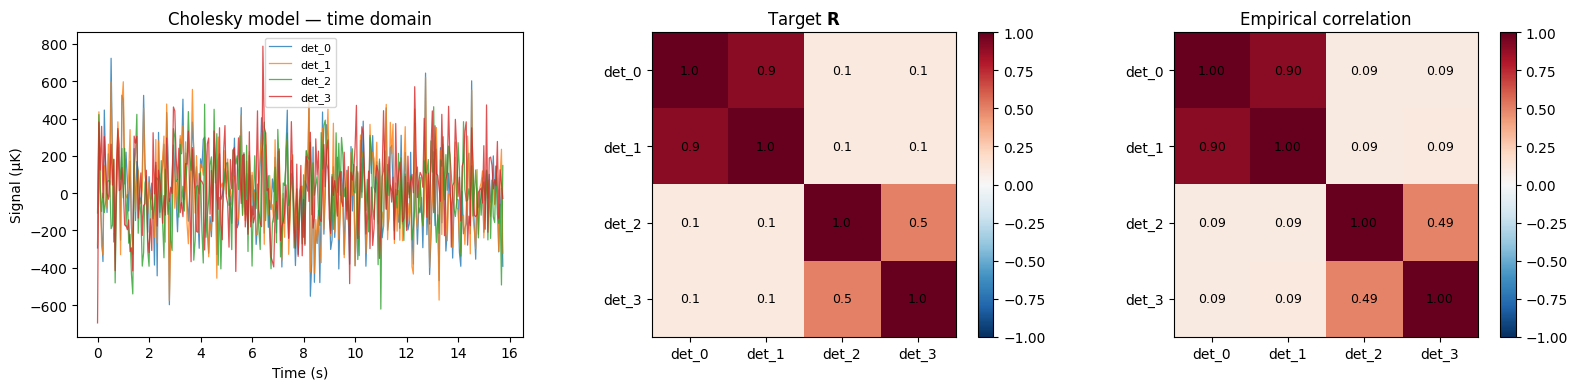

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Time domain
for i in range(n_dets):
    axes[0].plot(
        t_short,
        tod_chol[i, :300] * 1e6,
        lw=0.9,
        alpha=0.8,
        color=colors[i],
        label=f"det_{i}",
    )
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Signal (µK)")
axes[0].set_title("Cholesky model — time domain")
axes[0].legend(fontsize=8)

# Target matrix
im0 = axes[1].imshow(R, vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar(im0, ax=axes[1])
axes[1].set_title("Target $\\mathbf{R}$")
for i in range(n_dets):
    for j in range(n_dets):
        axes[1].text(j, i, f"{R[i, j]:.1f}", ha="center", va="center", fontsize=9)

# Empirical matrix
im1 = axes[2].imshow(corr_emp, vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar(im1, ax=axes[2])
axes[2].set_title("Empirical correlation")
for i in range(n_dets):
    for j in range(n_dets):
        axes[2].text(
            j, i, f"{corr_emp[i, j]:.2f}", ha="center", va="center", fontsize=9
        )

for ax in axes[1:]:
    ax.set_xticks(range(n_dets))
    ax.set_yticks(range(n_dets))
    ax.set_xticklabels([f"det_{i}" for i in range(n_dets)])
    ax.set_yticklabels([f"det_{i}" for i in range(n_dets)])

plt.tight_layout()
plt.show()

## 5. Reproducibility

Passing the same `random_seed` to `Simulation` guarantees identical noise realisations across runs. The `dets_random` list can also be saved and restored for fine-grained control.

In [16]:
def run_sim(seed):
    sim_ = lbs.Simulation(
        base_path="./output_noise_nb",
        start_time=0,
        duration_s=100,
        random_seed=seed,
    )
    sim_.create_observations(detectors=[det_oof])
    sim_.add_noise(noise_type="one_over_f")
    return sim_.observations[0].tod[0].copy()


tod_a = run_sim(seed=99)
tod_b = run_sim(seed=99)  # same seed → identical
tod_c = run_sim(seed=100)  # different seed → different

print(f"Same seed — max |diff|: {np.abs(tod_a - tod_b).max():.2e}  (should be 0)")
print(f"Diff seed — max |diff|: {np.abs(tod_a - tod_c).max():.2e}  (should be > 0)")

Same seed — max |diff|: 0.00e+00  (should be 0)
Diff seed — max |diff|: 1.27e-03  (should be > 0)


## Summary

| Noise type | Function / method | Key parameters |
|------------|------------------|----------------|
| White | `add_noise_to_observations(..., noise_type="white")` | `net_ukrts` |
| 1/f | `add_noise_to_observations(..., noise_type="one_over_f")` | `net_ukrts`, `fknee_mhz`, `alpha`, `model`, `engine` |
| Correlated (common-mode) | `sim.add_noise(noise_type="correlated", correlation={"groups": ..., "rho": ...})` | `groups`, `rho`, `common_mode_type` |
| Correlated (Cholesky) | `sim.add_noise(noise_type="correlated", correlation={"corr_matrix": R})` | `corr_matrix` |

For full API details see the [noise documentation](https://litebird-sim.readthedocs.io/en/latest/noise.html).